=== ARなし RandomForest テスト性能 ===
MAE : 597.911335901961
RMSE: 668.3071134678682
R2  : -3.9267553685157717

=== 特徴量重要度 ===
         t : 0.666208
      year : 0.330176
     month : 0.003616


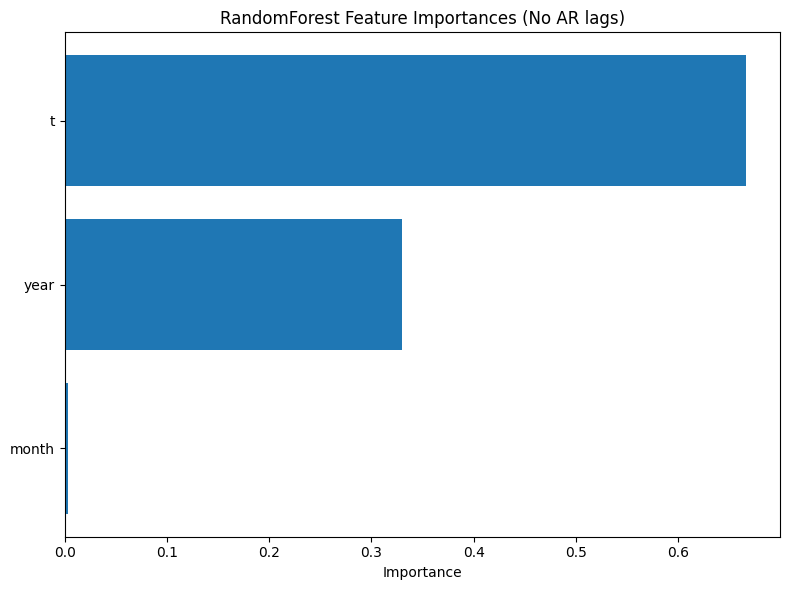

In [1]:
# ===== 設定 =====
CSV_PATH = "monthly_1950-01_2020-07.csv"
TEST_RATIO = 0.2
SEED = 0
# =================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# --- データ読み込み ---
df = pd.read_csv(CSV_PATH)
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").set_index("Date")

# Price をそのまま使用
y = df["Price"].astype(float)

# --- ARなし：最低限の特徴量作成 ---
# （必要なら自由に追加可能）
d = pd.DataFrame({
    "y": y,
    "year": df.index.year,
    "month": df.index.month,      # 月次データなので重要
    "t": range(len(df))           # トレンド（整数）
})

d = d.dropna()

X = d.drop(columns=["y"]).values
target = d["y"].values
feature_names = list(d.drop(columns=["y"]).columns)

# --- 時系列分割 ---
n = len(d)
split = int(n * (1 - TEST_RATIO))
X_train, X_test = X[:split], X[split:]
y_train, y_test = target[:split], target[split:]

# --- RandomForest 回帰 ---
model = RandomForestRegressor(
    n_estimators=300,
    random_state=SEED
)
model.fit(X_train, y_train)
pred = model.predict(X_test)

# --- 性能 ---
print("=== ARなし RandomForest テスト性能 ===")
print("MAE :", mean_absolute_error(y_test, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
print("R2  :", r2_score(y_test, pred))

# --- 特徴量重要度 ---
importances = model.feature_importances_
imp_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance")

print("\n=== 特徴量重要度 ===")
for _, row in imp_df.sort_values("importance", ascending=False).iterrows():
    print(f"{row['feature']:>10s} : {row['importance']:.6f}")

# --- プロット ---
plt.figure(figsize=(8, 6))
plt.barh(imp_df["feature"], imp_df["importance"])
plt.title("RandomForest Feature Importances (No AR lags)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()